In [1]:
# Step 1: Import Libraries:- 

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [2]:
# Step 2: Load Dataset:- 
df = pd.read_csv("Telco-Customer-Churn.csv")

In [3]:
# Step 3: Basic Data Understanding:- 
print(df.head())
print(df.info())
print(df.isnull().sum())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [4]:
# Step 4: Data Cleaning:- 
# drop customer id if present (not useful for prediction)
if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)

In [5]:
# Step 5: Encode Categorical Columns:- 

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

In [6]:
# Step 6: Split Features & Target:- 

X = df.drop('Churn', axis=1)
y = df['Churn']

In [7]:
# Step 7: Train-Test Split:- 

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [8]:
# Step 8: Train Models:- 
# Logistic Regression:- 

lr = LogisticRegression(max_iter=3000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

# Decision Tree:- 

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

# Random Forest:- 

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

Logistic Regression Accuracy: 0.8161816891412349
Decision Tree Accuracy: 0.7274662881476224
Random Forest Accuracy: 0.7984386089425124


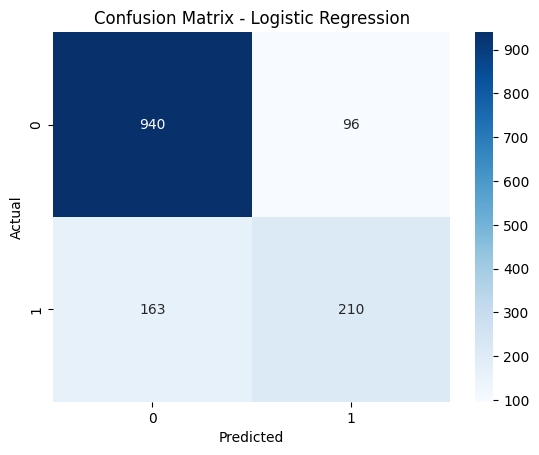

              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1036
           1       0.66      0.49      0.56       373

    accuracy                           0.80      1409
   macro avg       0.75      0.70      0.71      1409
weighted avg       0.79      0.80      0.79      1409



In [9]:
# Step 9: Model Evaluation:- 

# Accuracy:- 
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

# Confusion Matrix (Random Forest):- 
cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

# Classification Report:- 
print(classification_report(y_test, y_pred_rf))

In [10]:
# Step 10: Feature Importance:- 
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importance)

             Feature  Importance
17    MonthlyCharges    0.176539
4             tenure    0.174955
18      TotalCharges    0.167721
14          Contract    0.081976
16     PaymentMethod    0.051153
8     OnlineSecurity    0.048006
11       TechSupport    0.043074
9       OnlineBackup    0.027847
0             gender    0.027486
15  PaperlessBilling    0.026085
7    InternetService    0.024514
2            Partner    0.024310
6      MultipleLines    0.022742
10  DeviceProtection    0.021655
3         Dependents    0.020808
1      SeniorCitizen    0.020452
13   StreamingMovies    0.018083
12       StreamingTV    0.017067
5       PhoneService    0.005527
